<h1>Sum of Squares</h1>
<h3>January 2024</h3>

[Sum of Squares puzzle](https://www.janestreet.com/puzzles/sum-of-squares-index/)

<div style="text-align:center">
  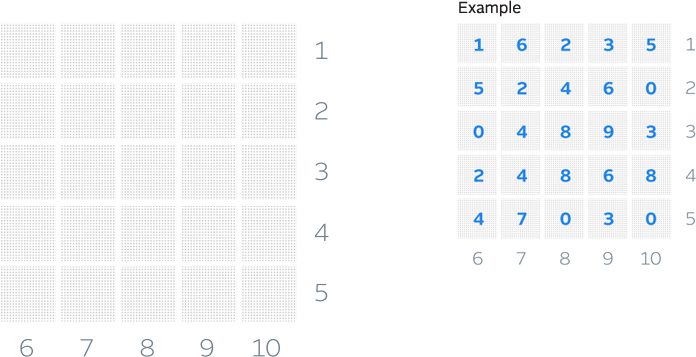
</div>

Place a digit in each of the 25 spots in the below 5×5 grid, so that each 5-digit number (leading zeroes are ok) reading across and reading down is divisible by the number outside the grid, trying to maximize the sum of the 25 numbers you enter. An example of a completed grid with sum 100 is presented on the right.

Please submit your answer (along with any other comments you want to provide) as an ordered pair of your sum, and your 25 numbers, reading left to right, top to bottom.

Example submission: (100,1623552460048932486847030)

## Solution

There are $25^{10} \approx 10^{14}$ possible combinations. Assuming we could process $10^6$ combinations per second, it would still take $10^8$ seconds or 3.17 years which is unfeasible.

A first approach would be to do a Depth First Search (DFS) with backtracking and pruning. In this approach, each branch of solutions is explored fully by adding one digit at a time, until a solution becomes unfeasible at which point we backtrack and prune, i.e. discard, the remaining branch.
This approach is also very time-consuming because we must discover all viable branches in order to be sure we have found the optimal solution that maximises the objective.

The best approach which leads to the answer within minutes is to use a max-head to dynamically construct combinations with decreasing total sum, stopping when we find the first valid combination.
This approach ensures that the first valid combination will be the one with the maximum sum by construction.

Before we begin, there are a number of constraints that reduce the state space we need to consider.

The heap structure and additional notions required to understand the solution are provided in the `heap_tutorial.ipynb`.

### Cell Constrains

Divisibility rules.


|Divisor | Rule                                                                                    |
|-|-----------------------------------------------------------------------------------------|
| 1 | No constraint                                                                           |
| 2 | Last digit is divisible by 2                                                            |
| 3 | Sum of digits is divisible by 3                                                         |
| 4 | Last two digits are divisible by 4                                                      |
| 5 | Last digit is 0 or 5                                                                    |
|6 | Divisible by 2 and 3 (last digit is divisible by 2 and sum of digits is divisible by 3) |
|7| No rule, needs to be checked                                                            |
| 8| Last three digits divisible by 8                                                        |
| 9| Sum of digits divisible by 9                                                            |
| 10 | Last digit is 0                                                                         |

Let $X$ by the $5 \times 5$ array of digits (0-indexed). The divisibility rules translate into the following constraints

$$
X[4,4] = 0, \quad (10 \times X[3,3] + X[3, 4])\mod 4 \equiv 0,
$$
$$
(100 \times (X[2,2]\mod 8) + 10 \times (X[3, 2] \mod 8) + X[4,2] \mod 8) \mod 8 \equiv 0
$$
$$
X[1,4],\; X[3, 4], \;X[4,0],\; X[4, 2] \in \{0, 2, 4, 6, 8\}
$$

###

In [3]:
from typing import Dict, Tuple
CELL_TO_MULTIPLIERS = {(j, i): (j+1, i+6) for i in range(5) for j in range(5)}
import time
# keep the possible numbers in a global dictionary. Do a full loop and then update the global dictionary to know which paths have been globally pruned
_ALL_ = list(range(9, -1, -1))
OPTIONS = dict(((i, j), _ALL_) for i in range(5) for j in range(5))
FIXED = {
    (4, 4): [0],
    (3, 4): [8, 6, 4, 2, 0],
    (1, 4): [8, 6, 4, 2, 0],
    (4, 0): [8, 6, 4, 2, 0],
    (2, 0): [8, 6, 4, 2, 0],
}
OPTIONS.update(FIXED)

def get_multipliers(indices: tuple) -> tuple:
    return CELL_TO_MULTIPLIERS[indices]


def get_max_array(options: Dict[tuple, list]) -> list:
    sum_array = []
    running_sum = 0
    for i in range(4, -1, -1):
        for j in range(4, -1, -1):
            current_max = max(options[(i,j)])
            running_sum += current_max
            sum_array.append(running_sum)
    return sum_array


def is_valid(numbers: list, multiplier: int) -> bool:
    if multiplier == 10:
        return numbers[-1] == 0
    elif multiplier == 9:
        if any([number == None for number in numbers]):
            return True
        return sum(numbers) % 9 == 0
    elif multiplier == 8:
        if numbers[-3] == None or numbers[-2] == None:
            return True
        return ((4 * numbers[-3] + 2 * numbers[-2] + numbers[-1]) % 8) == 0
    elif multiplier == 7:
        if any([number == None for number in numbers]):
            return True
        return (4 * numbers[0] + 6 * numbers[1] + 2 * numbers[2] + 3 * numbers[3] + numbers[4]) % 7 == 0
    elif multiplier == 6:
        if any([number == None for number in numbers]):
            return True
        return sum(numbers) % 6 == 0
    elif multiplier == 5:
        return numbers[-1] in {5, 0}
    elif multiplier == 4:
        if numbers[-2] == None:
            return True
        return (10 * numbers[-2] + numbers[-1]) % 4 == 0
    elif multiplier == 3:
        if any([number == None for number in numbers]):
            return True
        return sum(numbers) % 3 == 0
    elif multiplier == 2:
        return numbers[-1] % 2 == 0
    else:
        return True

def select_next(numbers: list, indices: tuple, options: dict) -> Tuple[list, tuple]:
    # missing constraints for multipliers (3, 4, 6, 7, 8, 9)
    multipliers = get_multipliers(indices)
    row_multiplier = min(multipliers)
    col_multiplier = max(multipliers)
    # to_test = set(multipliers).intersection({3, 4, 6, 7, 8, 9})
    valid_options = options[indices]
    i, j = indices
    valid_rows = []
    valid_cols = []
    found = False
    for val in valid_options:
        numbers[i][j] = val
        print(val)
        time.sleep(5)
        valid_row =  is_valid(numbers[i][:], row_multiplier)
        valid_col = is_valid(numbers[:][j], col_multiplier)
        valid_rows.append(val) if valid_row else None
        valid_cols.append(val) if valid_col else None
        if valid_row and valid_col:
            found = True
            break
    if found:
        if j == 0:
            i -= 1
            j = 4
        else:
            j -= 1
        return numbers, (i, j)
    if not valid_cols: # todo: update the dict too!!!!
        # keep the column, go row + 1
        i += 1
        options[(i, j)].pop(numbers[i][j])
        # make the 6 cells 0 starting from
        for j_prime in range(0, j, 1):
            numbers[i][j_prime] = None
        for j_prime in range(4-j, -1, -1):
            numbers[i - 1][j_prime] = None
        return numbers, (i, j)
    else:
        # keep the row and go back one column => column + 1
        assert j != 4
        j += 1
        options[(i, j)].pop(numbers[i][j])
        numbers[i][j] = None
        numbers[i][j-1] = None
        return numbers, (i, j)

def run():
    numbers = [[None for _ in range(5)] for _ in range(5)]
    indices = (4, 4)
    current_max = -1
    options = OPTIONS.copy()
    max_possible = get_max_array(options=options)
    i = 4
    j = 4
    while i > 0: # rows
        while j > 0: # columns
            numbers, (i, j) = select_next(numbers=numbers, indices=indices, options=options)
            print(i, j)
            print(numbers)
    assert all([x is not None for y in numbers for x in y]), f'No numbers should be None'
    current_max = sum([x for y in numbers for x in y])
    return current_max, numbers

c, n = run()

0


KeyboardInterrupt: 

In [17]:
a = [[1, 2,], [3, 4]]
a[1][:]

[3, 4]

In [11]:
import cvxpy as cp
import numpy as np

# TODO: set sizes/ranges from puzzle

x = cp.Variable((5, 5), integer=True)

t = cp.Variable((5,1), integer=True, nonneg=True)
t_T = cp.Variable((1, 5), integer=True, nonneg=True)

Acol = cp.Constant(np.ones((5, 1), dtype=int))  # for row sums
Arow = cp.Constant(np.ones((1, 5), dtype=int))  # for column sums
print(Arow)
m1 = cp.Constant(np.array(np.arange(1, 6), dtype=int).reshape(5, 1))
m2 = cp.Constant(np.array(np.arange(6, 11), dtype=int).reshape(1, 5))
constraints = [
    x >= 0, x <= 9,
    x @ Acol == cp.multiply(m1, t),          # (5,1) == (5,1)
    Arow @ x == cp.multiply(m2, t_T),        # (1,5) == (1,5)
]


[[1. 1. 1. 1. 1.]]


In [12]:

objective = cp.Maximize(cp.sum(x))
prob = cp.Problem(objective, constraints)
val = prob.solve(solver=cp.MOSEK, verbose=True)

print("status:", prob.status)
print("objective:", val)
print("x:", x.value)


(CVXPY) Feb 09 02:27:48 PM: Your problem has 35 variables, 60 constraints, and 0 parameters.
(CVXPY) Feb 09 02:27:48 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 09 02:27:48 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 09 02:27:48 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 09 02:27:48 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Feb 09 02:27:48 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Feb 09 02:27:48 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> MOSEK
(CVXPY) Feb 09 02:27:48 PM: Applying reduction FlipObjective
(CVXPY) Feb 09 02:27:48 PM: Applying reduction Dcp2Cone
(CVXPY) Feb 09 02:27:48 PM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 09 02:27:48 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 09 02:27:48 PM: Applying 

                                     CVXPY                                     
                                     v1.8.1                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
status: optimal
objective: 209.0
x: [[9. 9. 9. 9. 9.]
 [7. 6. 4. 9. 4.]
 [9. 9. 9. 9. 9.]
 [8. 9. 9. 9. 9.]
 [9. 9. 9.

In [13]:
X = x.value
for i in range(5):
    print(np.sum(X[i, ::]) % (i+1), end=', ')

for i in range(5):
    print(np.sum(X[::, i]) % (i+6), end=',')

0.0, 0.0, 0.0, 0.0, 0.0, 0.0,0.0,0.0,0.0,0.0,

In [ ]:
x = np.repeat(-1, 25).reshape(5,5)

In [ ]:
col = np.array([10**i for i in range(4, -1, -1)]).reshape(5, 1)
def check_row(row: np.ndarray, i: int):
    if np.any(row == -1):
        return True
    number = row @ col
    return number % i

In [ ]:
col

In [ ]:
row = np.array([5, 2, 6, 1, 0])


In [ ]:
row @ col

In [ ]:
_ %10

In [ ]:
ROW_DIV = [1, 2, 3, 4, 5]
COL_DIV = [6, 7, 8, 9, 10]
W = [10000, 1000, 100, 10, 1]

def row_num(g, r):
    if any(g[r][c] is None for c in range(5)): return None
    return sum(g[r][c] * W[c] for c in range(5))

def col_num(g, c):
    if any(g[r][c] is None for r in range(5)): return None
    return sum(g[r][c] * W[r] for r in range(5))

def init_grid(fixed):
    g = [[None]*5 for _ in range(5)]
    for (r, c), d in fixed.items():
        g[r][c] = d
    if not partial_ok(g):
        raise ValueError("Fixed digits already violate a completed row/col constraint.")
    return g

def last_digit_ok(divisor, last_digit):
    if last_digit is None:
        return True
    if divisor % 10 == 0:
        return last_digit == 0
    if divisor % 5 == 0:
        return last_digit in (0, 5)
    if divisor % 2 == 0:
        return last_digit % 2 == 0
    return True

def partial_ok(g):
    # quick last-digit pruning
    for r in range(5):
        if not last_digit_ok(ROW_DIV[r], g[r][4]):  # row last digit
            return False
    for c in range(5):
        if not last_digit_ok(COL_DIV[c], g[4][c]):  # col last digit
            return False

    # full checks when complete
    for r in range(5):
        n = row_num(g, r)
        if n is not None and n % ROW_DIV[r] != 0:
            return False
    for c in range(5):
        n = col_num(g, c)
        if n is not None and n % COL_DIV[c] != 0:
            return False

    return True


In [ ]:

best_sum = -1
best_grid = None

def search(g, pos=0, current_sum=0):
    global best_sum, best_grid
    if pos == 25:
        if current_sum > best_sum:
            best_sum = current_sum
            best_grid = [row[:] for row in g]
        return

    r, c = divmod(pos, 5)

    # If this cell is fixed, just continue.
    if g[r][c] is not None:
        search(g, pos+1, current_sum + g[r][c])
        return

    for d in range(9, -1, -1):
        g[r][c] = d
        if partial_ok(g):
            search(g, pos+1, current_sum + d)
        g[r][c] = None

# Example fixed digits:
# bottom-right must be 0 if the last column divisor is 10
fixed = {(4, 4): 0}

g = init_grid(fixed)
start_sum = sum(d for row in g for d in row if d is not None)
search(g, 0, 0)  # current_sum handled cell-by-cell including fixed

print("best_sum:", best_sum)
for row in best_grid:
    print(row)


In [ ]:
ROW_DIV = [1, 2, 3, 4, 5]      # change if your puzzle differs
COL_DIV = [6, 7, 8, 9, 10]     # change if your puzzle differs

def allowed_last_digits(divisor):
    if divisor % 10 == 0:
        return [0]
    if divisor % 5 == 0:
        return [0, 5]
    if divisor % 2 == 0:
        return [0, 2, 4, 6, 8]
    return list(range(10))

def solve():
    grid = [[None]*5 for _ in range(5)]
    row_mod = [0]*5
    col_mod = [0]*5

    best_sum = -1
    best_grid = None

    def backtrack(pos, current_sum):
        nonlocal best_sum, best_grid

        if pos == 25:
            if current_sum > best_sum:
                best_sum = current_sum
                best_grid = [row[:] for row in grid]
            return

        r, c = divmod(pos, 5)

        # digit choices (maximize sum)
        if c == 4:
            cand = allowed_last_digits(ROW_DIV[r])
        else:
            cand = list(range(10))
        if r == 4:
            cand = [d for d in cand if d in allowed_last_digits(COL_DIV[c])]

        for d in range(9, -1, -1):
            if d not in cand:
                continue

            old_rm, old_cm = row_mod[r], col_mod[c]
            row_mod[r] = (row_mod[r]*10 + d) % ROW_DIV[r]
            col_mod[c] = (col_mod[c]*10 + d) % COL_DIV[c]

            # if row/col completed, enforce divisibility now
            if (c == 4 and row_mod[r] != 0) or (r == 4 and col_mod[c] != 0):
                row_mod[r], col_mod[c] = old_rm, old_cm
                continue

            grid[r][c] = d
            backtrack(pos+1, current_sum + d)
            grid[r][c] = None

            row_mod[r], col_mod[c] = old_rm, old_cm

    backtrack(0, 0)
    return best_sum, best_grid

def verify(grid):
    # build numbers
    rows = [int("".join(str(grid[r][c]) for c in range(5))) for r in range(5)]
    cols = [int("".join(str(grid[r][c]) for r in range(5))) for c in range(5)]
    ok_rows = [rows[r] % ROW_DIV[r] == 0 for r in range(5)]
    ok_cols = [cols[c] % COL_DIV[c] == 0 for c in range(5)]
    return {
        "sum_digits": sum(sum(row) for row in grid),
        "rows": rows, "cols": cols,
        "row_ok": ok_rows, "col_ok": ok_cols,
        "all_ok": all(ok_rows) and all(ok_cols),
        "submission": (sum(sum(row) for row in grid),
                       "".join(str(grid[r][c]) for r in range(5) for c in range(5)))
    }

if __name__ == "__main__":
    s, g = solve()
    print("best sum:", s)
    for row in g: print(row)
    print(verify(g))


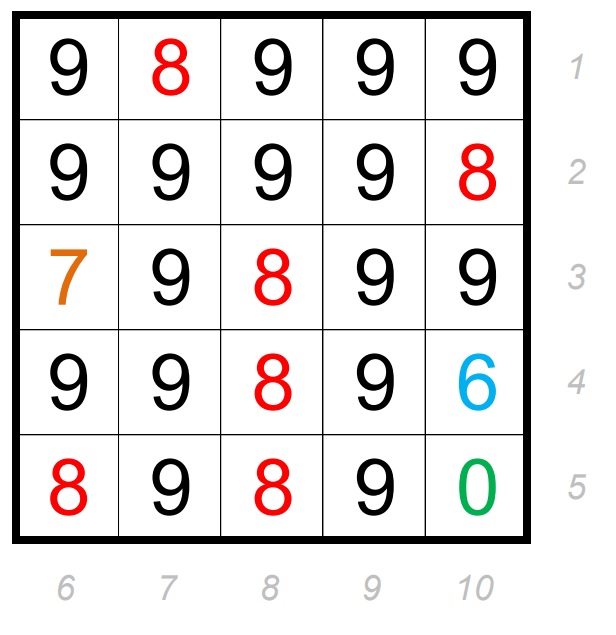